ENVIRONMENT SETUP AND IMPORTING LIBRARIES

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv('car data.csv')
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


DATA EXPLORATION

In [10]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Columns: 106 entries, Year to Transmission_Manual
dtypes: bool(101), float64(2), int64(3)
memory usage: 41.6 KB


,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [8]:
df.isnull().sum()

Year                       0
Selling_Price              0
Present_Price              0
Driven_kms                 0
Owner                      0
                          ..
Car_Name_xcent             0
Fuel_Type_Diesel           0
Fuel_Type_Petrol           0
Selling_type_Individual    0
Transmission_Manual        0
Length: 106, dtype: int64

DATA PREPROCESSING

In [15]:
df = df.dropna()
df_encoded = pd.get_dummies(df, drop_first=True)
print(df_encoded.head())

   Year  Selling_Price  Present_Price  Driven_kms  Owner  Car_Name_Activa 3g  \
0  2014           3.35           5.59       27000      0               False   
1  2013           4.75           9.54       43000      0               False   
2  2017           7.25           9.85        6900      0               False   
3  2011           2.85           4.15        5200      0               False   
4  2014           4.60           6.87       42450      0               False   

   Car_Name_Activa 4g  Car_Name_Bajaj  ct 100  Car_Name_Bajaj Avenger 150  \
0               False                   False                       False   
1               False                   False                       False   
2               False                   False                       False   
3               False                   False                       False   
4               False                   False                       False   

   Car_Name_Bajaj Avenger 150 street  ...  Car_Name_swif

SPLITTING DATA AND MODEL TRAINING

In [11]:
X = df_encoded.drop('Selling_Price', axis=1)
y = df_encoded['Selling_Price']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training data size: {X_train.shape}")
print(f"Testing data size: {X_test.shape}")

Training data size: (240, 105)
Testing data size: (61, 105)


In [14]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Model is successfully traind!")

Model is successfully traind!


MODEL EVALUATION AND VISUALIZATION

In [20]:
y_pred = model.predict(X_test)

In [21]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error(MAE): {mae:.2f}")
print(f"Mean Squared Error(MSE): {mse:.2f}")
print(f"R2 Score(Accuracy): {r2:.2f}")

Mean Absolute Error(MAE): 2.04
Mean Squared Error(MSE): 9.22
R2 Score(Accuracy): 0.60


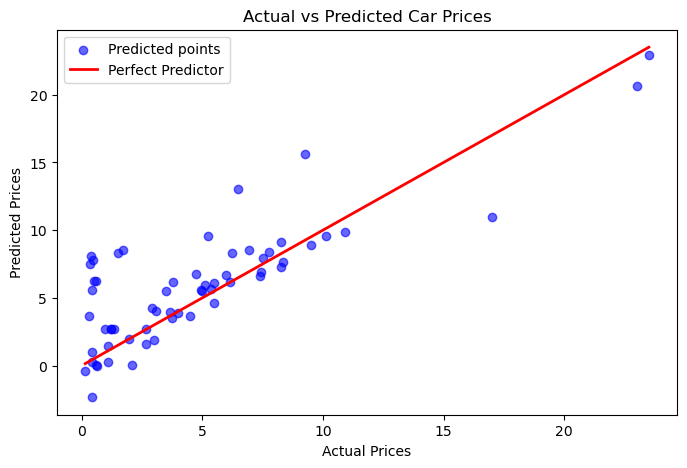

In [27]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, color ='blue', alpha=0.6, label = 'Predicted points')
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()], color='red', lw=2, label = 'Perfect Predictor')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Car Prices")
plt.legend()
plt.show()